# EDA de prueba — Audiencias de Familia (PJUD, C.A. Valparaíso, 2015–2025)
Siguiendo la estructura de la Clase 4 (pregunta → reconocimiento → descriptivo → gráficos → hallazgos).

**Pregunta guía:** ¿qué tan rápido agenda el sistema de Familia, dónde es más lento y cómo cambió con la pandemia y la videoconferencia?

- **Y:** `PLAZO_AGENDAMIENTO` (días entre programación y realización de la audiencia) → proxy de eficiencia/espera.
- **X:** tribunal, tipo de audiencia, videoconferencia.
- **T:** año (`ANO_PROCESO`).

In [1]:
from pathlib import Path
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

DATA = Path('../data/raw/parquet/audiencias_realizadas_competencia_detalle.parquet')
df = pd.read_parquet(DATA)
df.head()

,COD_CORTE,CORTE,COD_TRIBUNAL,TRIBUNAL,RIT,TIPO_PROCEDIMIENTO,TIPO_AUDIENCIA,FECHA_INGRESO,FECHA_PROGRAMACION,FECHA_AUDIENCIA,PLAZO_AGENDAMIENTO,HORA_INICIO,HORA_FIN,ANO_AUDIENCIA,COMPETENCIA,TOTAL_AUDIENCIAS,ID_CAUSA,RUC,ID_AUDIENCIA,VIDEOCONFERENCIA,ANO_PROCESO,FECHA_FIRMA
0,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-1-2015,Adopción,Audiencia Preparatoria,2015-02-06,2015-02-09,2015-02-19,10.0,10:11:00,10:24:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
1,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-3-2015,Adopción,Audiencia Preparatoria,2015-06-04,2015-06-10,2015-06-17,7.0,11:51:00,11:55:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
2,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-5-2015,Adopción,Audiencia de Juicio,2015-08-04,2015-09-14,2015-10-06,18.0,09:27:00,09:46:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
3,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-5-2015,Adopción,Audiencia Preparatoria,2015-08-04,2015-08-14,2015-09-14,26.0,11:12:00,11:26:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT
4,30,C.A. DE VALPARAÍSO,1261,JUZGADO DE FAMILIA CASABLANCA,A-6-2015,Adopción,Audiencia,2015-09-14,2015-11-18,2015-11-30,11.0,12:44:00,12:47:00,2015.0,Familia,1,<NA>,NaN,<NA>,NaN,2015,NaT


## 1. Reconocimiento del dataset
Unidad de análisis: **una audiencia realizada**. Revisamos tipos y completitud.

In [2]:
print('Dimensiones:', df.shape)
print('Causas únicas (RIT):', df['RIT'].nunique())
print('Tribunales:', df['COD_TRIBUNAL'].nunique())
print()
print((df.isna().mean()*100).round(1).sort_values(ascending=False).head(8).to_string())

Dimensiones: (466178, 22)
Causas únicas (RIT): 128401
Tribunales: 15

RUC                   90.5
ID_CAUSA              71.6
FECHA_FIRMA           62.7
ID_AUDIENCIA          62.3
VIDEOCONFERENCIA      53.2
FECHA_INGRESO          9.3
FECHA_PROGRAMACION     1.7
FECHA_AUDIENCIA        0.3


## 2. Limpieza mínima necesaria para graficar
Solo lo imprescindible: texto normalizado, `VIDEOCONFERENCIA` a booleano y plazos válidos (≥0; los negativos son errores de registro).

In [3]:
def norm(s):
    if pd.isna(s): return s
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return s.strip().upper()

df['TRIBUNAL_N'] = df['TRIBUNAL'].map(norm)
df['TIPO_AUDIENCIA_N'] = df['TIPO_AUDIENCIA'].map(norm)

map_vc = {'SI': True, '1.0': True, '1,0': True, 'NO': False, '0.0': False, '0,0': False}
df['VIDEO'] = df['VIDEOCONFERENCIA'].map(map_vc)   # NaN = dato no existente (pre-2021)

print('Plazos negativos:', (df['PLAZO_AGENDAMIENTO'] < 0).sum())
d = df[df['PLAZO_AGENDAMIENTO'].between(0, 365)].copy()
print('Filas usadas:', len(d), f'({len(d)/len(df):.1%})')
d['PLAZO_AGENDAMIENTO'].describe().round(1)

Plazos negativos: 16


Filas usadas: 466065 (100.0%)


count    466065.0
mean         31.4
std          25.0
min           0.0
25%          12.0
50%          26.0
75%          43.0
max         339.0
Name: PLAZO_AGENDAMIENTO, dtype: float64

## 3. Estadística descriptiva de Y (plazo de agendamiento)

In [4]:
y = d['PLAZO_AGENDAMIENTO']
pd.Series({'media': y.mean(), 'mediana': y.median(), 'P75': y.quantile(.75),
           'P90': y.quantile(.90), 'max': y.max(), 'skewness': y.skew()}).round(2)

media        31.4
mediana      26.0
P75          43.0
P90          64.0
max         339.0
skewness      1.7
dtype: float64

## 4. Gráfico 1 — Evolución anual del plazo de espera (con volumen de audiencias)
**Pregunta:** ¿el sistema se ha vuelto más lento en el tiempo?

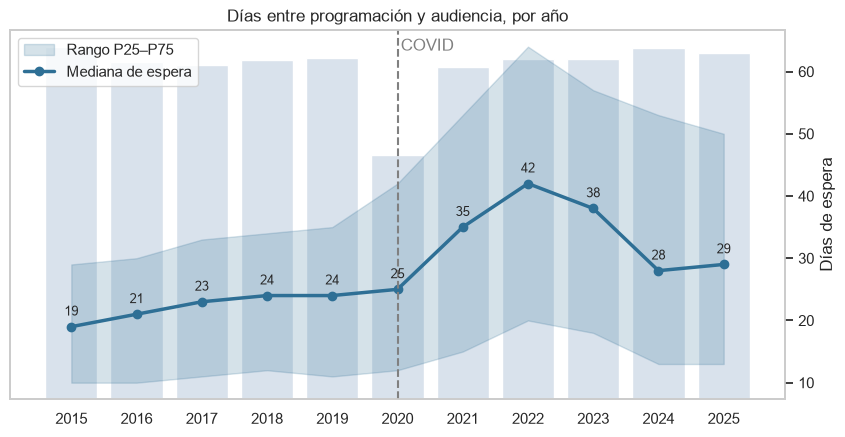

,mediana,p25,p75,n
ANO_PROCESO,,,,
2015,19.0,10.0,29.0,44824
2016,21.0,10.0,30.0,42948
2017,23.0,11.0,33.0,42569
2018,24.0,12.0,34.0,43256
2019,24.0,11.0,35.0,43448
2020,25.0,12.0,42.0,31080
2021,35.0,15.0,53.0,42365
2022,42.0,20.0,64.0,43374
2023,38.0,18.0,57.0,43380


In [5]:
anual = d.groupby('ANO_PROCESO').agg(mediana=('PLAZO_AGENDAMIENTO', 'median'),
                                     p25=('PLAZO_AGENDAMIENTO', lambda s: s.quantile(.25)),
                                     p75=('PLAZO_AGENDAMIENTO', lambda s: s.quantile(.75)),
                                     n=('PLAZO_AGENDAMIENTO', 'size'))

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(anual.index, anual['n'], color='#D9E2EC', label='N° audiencias', zorder=0)
ax.set_yticks([]); ax.set_ylabel('')
ax.grid(False)
ax2 = ax.twinx()
ax2.fill_between(anual.index, anual['p25'], anual['p75'], color='#2E6F95', alpha=.2, label='Rango P25–P75')
ax2.plot(anual.index, anual['mediana'], marker='o', color='#2E6F95', lw=2.5, label='Mediana de espera')
for x, v in anual['mediana'].items():
    ax2.annotate(f'{v:.0f}', (x, v), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)
ax2.axvline(2020, ls='--', color='gray'); ax2.text(2020.05, ax2.get_ylim()[1]*.95, 'COVID', color='gray')
ax2.set(ylabel='Días de espera', xlabel='Año', title='Días entre programación y audiencia, por año')
ax2.grid(False)
ax2.legend(loc='upper left'); plt.xticks(anual.index); plt.show()
anual.round(1)

## 5. Gráfico 2 — Brecha de eficiencia entre tribunales
**Pregunta:** ¿dónde espera más un usuario? Mediana y P75 de espera por tribunal (Top 12 por volumen), período post-pandemia 2022–2025 para comparar la situación actual.

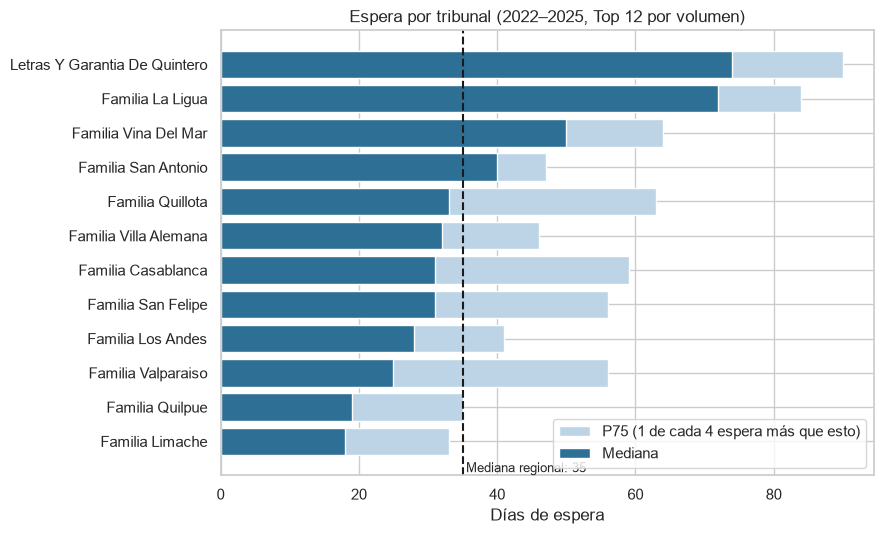

,mediana,p75,n
TRIBUNAL_N,,,
Familia Limache,18.0,33.0,6395
Familia Quilpue,19.0,35.0,12816
Familia Valparaiso,25.0,56.0,32527
Familia Los Andes,28.0,41.0,16240
Familia San Felipe,31.0,56.0,8623
Familia Casablanca,31.0,59.0,8430
Familia Villa Alemana,32.0,46.0,12319
Familia Quillota,33.0,63.0,16752
Familia San Antonio,40.0,47.0,10637


In [6]:
rec = d[d['ANO_PROCESO'] >= 2022]
top = rec['TRIBUNAL_N'].value_counts().head(12).index
t = (rec[rec['TRIBUNAL_N'].isin(top)].groupby('TRIBUNAL_N')['PLAZO_AGENDAMIENTO']
        .agg(mediana='median', p75=lambda s: s.quantile(.75), n='size')
        .sort_values('mediana'))
t.index = t.index.str.replace('JUZGADO DE ', '', regex=False).str.title()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(t.index, t['p75'], color='#BCD4E6', label='P75 (1 de cada 4 espera más que esto)')
ax.barh(t.index, t['mediana'], color='#2E6F95', label='Mediana')
med_global = rec['PLAZO_AGENDAMIENTO'].median()
ax.axvline(med_global, ls='--', color='k'); ax.text(med_global+.5, -0.9, f'Mediana regional: {med_global:.0f}', fontsize=9)
ax.set(xlabel='Días de espera', title='Espera por tribunal (2022–2025, Top 12 por volumen)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
t.round(1)

## 6. Gráfico 3 — Videoconferencia: adopción y efecto en la espera
**Pregunta:** ¿la modalidad remota se consolidó y las audiencias remotas esperan distinto que las presenciales? (la variable existe desde 2021)

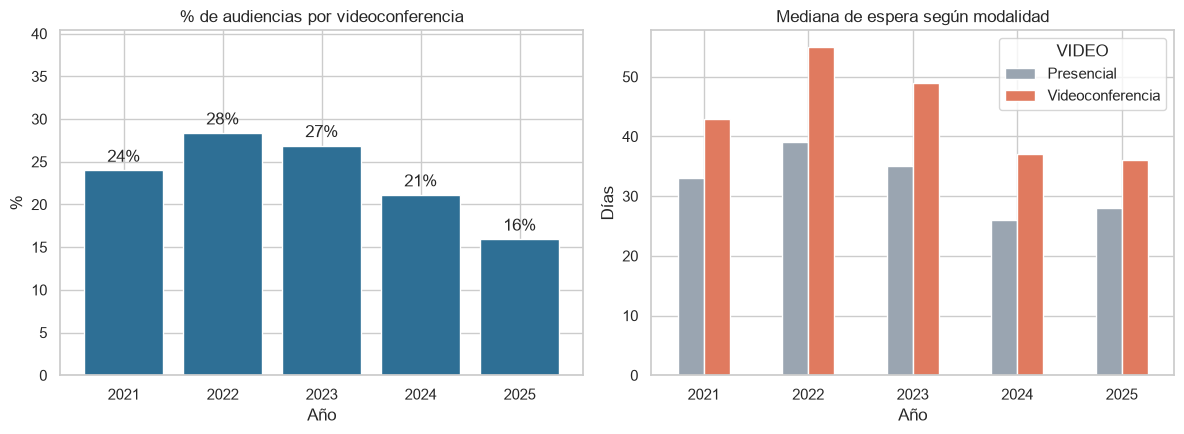

VIDEO,False,True
ANO_PROCESO,,
2021,33.0,43.0
2022,39.0,55.0
2023,35.0,49.0
2024,26.0,37.0
2025,28.0,36.0


In [7]:
v = d[d['VIDEO'].notna()].copy()
v['VIDEO'] = v['VIDEO'].astype(bool)
adop = v.groupby('ANO_PROCESO')['VIDEO'].mean()*100
esp = v.groupby(['ANO_PROCESO', 'VIDEO'])['PLAZO_AGENDAMIENTO'].median().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(adop.index, adop.values, color='#2E6F95')
for x, val in adop.items(): axes[0].text(x, val+1, f'{val:.0f}%', ha='center')
axes[0].set(title='% de audiencias por videoconferencia', xlabel='Año', ylabel='%', ylim=(0, max(adop)+12))
axes[0].set_xticks(adop.index)

esp.rename(columns={False: 'Presencial', True: 'Videoconferencia'}).plot(kind='bar', ax=axes[1], color=['#9AA5B1', '#E07A5F'], rot=0)
axes[1].set(title='Mediana de espera según modalidad', xlabel='Año', ylabel='Días')
plt.tight_layout(); plt.show()
esp.round(1)

## 7. De gráfico a hallazgo
Completar tras revisar los resultados: *Observación → Evidencia → Interpretación → Siguiente pregunta*.

## 8. Checklist antes de modelar
- Unidad de análisis clara (audiencia) ✔
- Y definida y depurada (plazos negativos fuera) ✔
- Comparación temporal, por grupo (tribunal) y por modalidad ✔
- Pendiente: controlar por tipo de audiencia/procedimiento, duración efectiva (`HORA_FIN − HORA_INICIO`) y tests estadísticos.